# Credit Scoring & Probability of Default Modeling

This notebook develops a credit risk model to estimate the **Probability of Default (PD)** for consumer loans, using supervised classification techniques and an industry-standard workflow.

The objective is not only to predict default risk, but to ensure that predicted probabilities are **interpretable, well calibrated, and usable for portfolio-level risk analysis**.

## The game plan is the following:

1. Business Understanding

   * Credit scoring vs Probability of Default (PD)
   * Default, LGD, EAD and Expected Loss
   * How banks use PD in lending decisions
   * Dataset selection and target definition
   * Linking features to credit risk intuition

2. **Exploratory Data Analysis (EDA)**

   * Default rate and class imbalance
   * Distribution of key financial variables
   * Relationship between borrower characteristics and default
   * Comparison of good vs bad borrowers

3. Feature Engineering (Risk-Oriented)

   * Feature scaling and normalisation
   * Creation of financial risk indicators
   * Outlier treatment
   * Categorical encoding
   * Initial feature selection

4. Modeling (Logistic Regression)

   * Baseline logistic regression model
   * Regularisation and cross-validation
   * ROC-AUC and precision–recall analysis

5. Model Calibration

   * Calibration curves
   * Probability calibration techniques
   * Before vs after calibration comparison

6. Model Interpretability

   * Permutation importance
   * SHAP global and local explanations
   * Business interpretation of risk drivers

7. Loan Portfolio Simulation

   * Portfolio assumptions
   * Expected Loss calculation
   * Comparison of acceptance and cut-off strategies
   * Business-focused risk visualisations

8. Results & Conclusions

   * Key modeling insights
   * Business implications
   * Limitations and next steps


In [23]:
import pandas

df = pandas.read_csv('loans_full_schema.csv')
df.info()

df.columns.tolist()

df[["balance", "annual_income"]].head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

,balance,annual_income
0,27015.86,90000.0
1,4651.37,40000.0
2,1824.63,40000.0


Before performing the exploratory analysis, variables were filtered to include only information available at application time or defined at loan origination. Variables generated after loan issuance or embedding prior risk decisions were excluded to ensure time consistency and avoid data leakage.

The exploratory analysis focuses on understanding the distribution and risk signal of candidate variables, without performing feature selection at this stage.


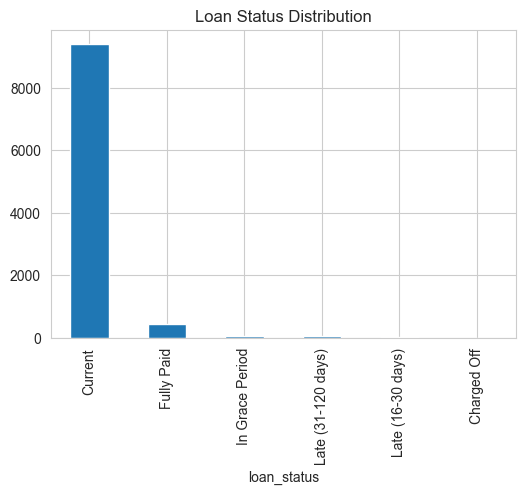

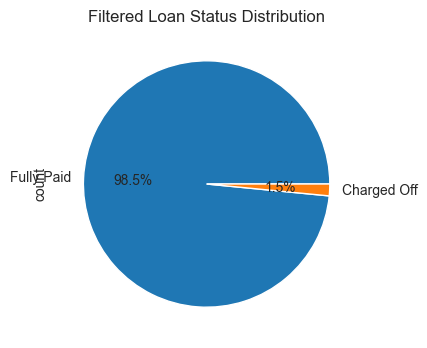

Class imbalance ratio (min/max): 0.0157


In [24]:
import matplotlib.pyplot as plt

# Default rate and class imbalance
loan_status = df["loan_status"].value_counts()

loan_status.plot(kind="bar")
plt.plot()
plt.title("Loan Status Distribution")
plt.show()

# Only see columns were loan_status is Charged Off vs Fully Paid
df_credit = df[df["loan_status"].isin(["Charged Off", "Fully Paid"])]
df_credit_loan_status = df_credit["loan_status"].value_counts()
df_credit_loan_status.plot(kind="pie", autopct="%1.1f%%")
plt.plot()
plt.title("Filtered Loan Status Distribution")
plt.show()


class_imbalance = df_credit_loan_status.min() / df_credit_loan_status.max()
print(f"Class imbalance ratio (min/max): {class_imbalance:.4f}")

## 2.1 Default rate and class imbalance

### Loan status distribution

In the original `loan_status` variable, most observations are labeled **Current**, meaning the loan is still active and we do not yet know the final outcome. There are also smaller groups such as **Fully Paid**, **In Grace Period**, **Late (16–30 days)**, **Late (31–120 days)**, and **Charged Off**.

From a modeling perspective, **“Current” is not usable as a clean label** for default modeling, because it mixes future good and bad outcomes. If we used it, we would introduce noise (and likely bias), since some of those “Current” loans will eventually default.

### Filtering to observed outcomes (Fully Paid vs Charged Off)

To define a proper target, we filter the dataset to loans with a **final observed outcome**, keeping only:

* **Fully Paid** --> non-default (good outcome)
* **Charged Off** --> default (bad outcome)

After this filtering, the class distribution becomes extremely skewed:

* **Fully Paid:** ~98.5%
* **Charged Off:** ~1.5%

This corresponds to a **class imbalance ratio (min/max) = 0.0157**, meaning the minority class (defaults) is only about **1.57%** of the majority class.

### Why this matters for modeling

This imbalance has several direct consequences:

* **Accuracy becomes misleading.**
  A naive model that predicts “Fully Paid” for everyone would already achieve ~98.5% accuracy, while being completely useless for detecting risk.

* **Default detection requires different metrics.**
  The evaluation must focus on metrics sensitive to the minority class, such as:

  * Recall / Precision for the default class
  * F1-score
  * ROC-AUC and especially PR-AUC (Precision–Recall AUC)
  * Confusion matrix-based business trade-offs

* **Probability calibration becomes important.**
  With strong imbalance, models can become overconfident or underconfident, so calibration checks (and sometimes calibration methods) are often necessary.

* **Class imbalance handling may be needed.**
  Depending on the chosen model and business objective, this may justify techniques such as:

  * **Class weights** (penalize default misclassification more)
  * **Resampling** strategies (e.g., SMOTE, undersampling)
  * **Threshold tuning** based on costs (not default 0.5 threshold)

### Business interpretation

Even though defaults are rare, they carry **disproportionately high financial impact**. This makes the problem asymmetric:

* Missing a true default (false negative) can be very expensive (loss given default, collections costs, capital allocation).
* Flagging a good borrower as risky (false positive) also has a cost (lost interest revenue, rejecting profitable customers), but is often less catastrophic.

So the modeling objective is typically **not** “maximize overall correctness”, but to find the best balance between:

* catching enough defaults early (risk control),
* while not rejecting too many good borrowers (profitability and growth).

### Key takeaway

> The dataset shows **extreme class imbalance (min/max = 0.0157)** after filtering to final outcomes.
> This confirms that credit scoring here is a **rare-event classification problem**, where model evaluation, training strategy, and decision thresholds must be designed around the minority (default) class rather than overall accuracy.




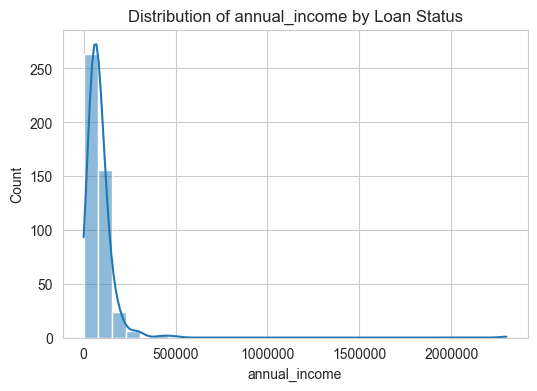

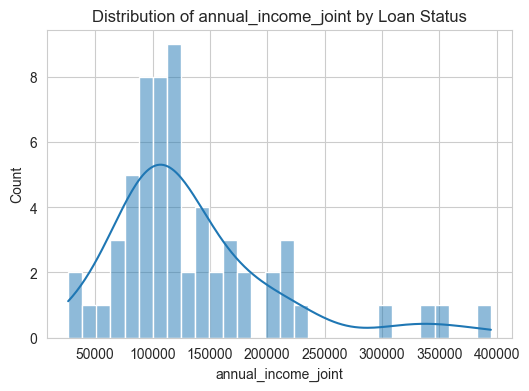

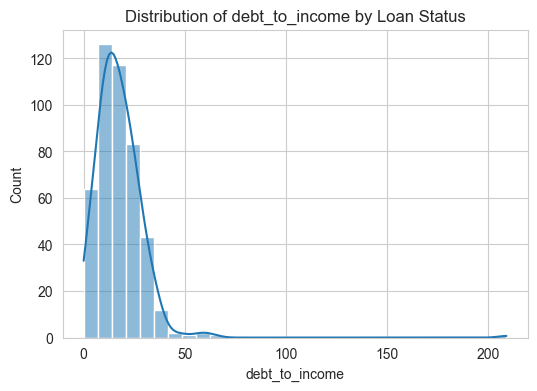

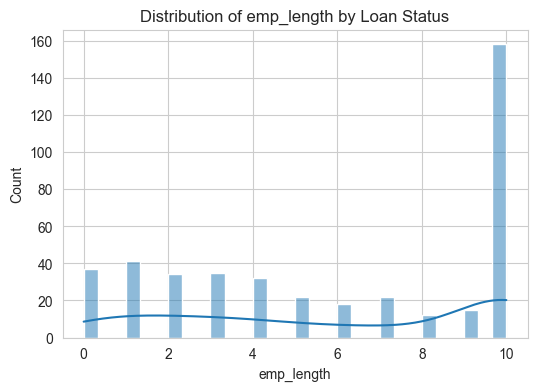

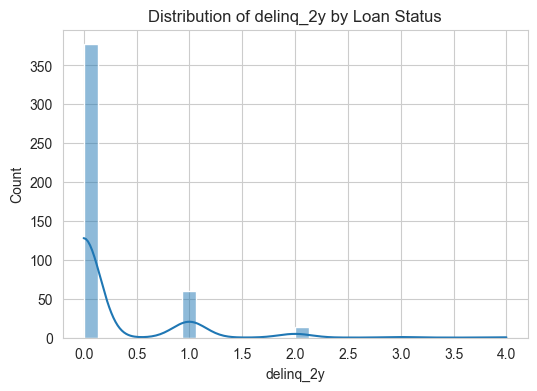

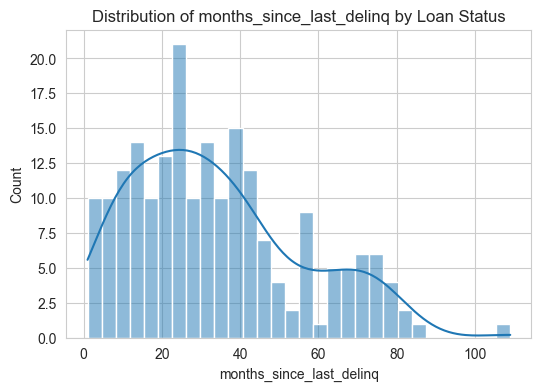

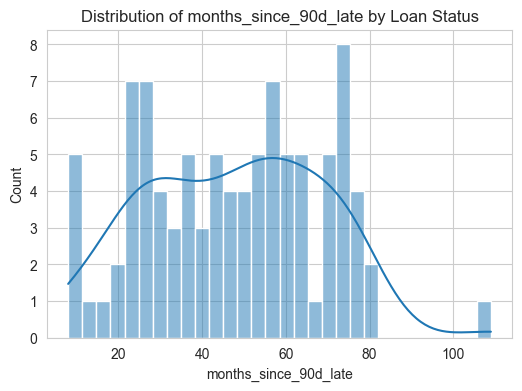

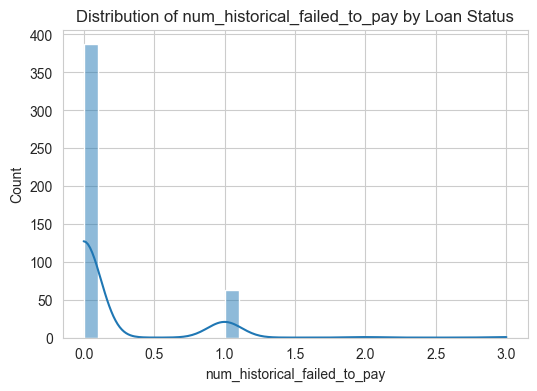

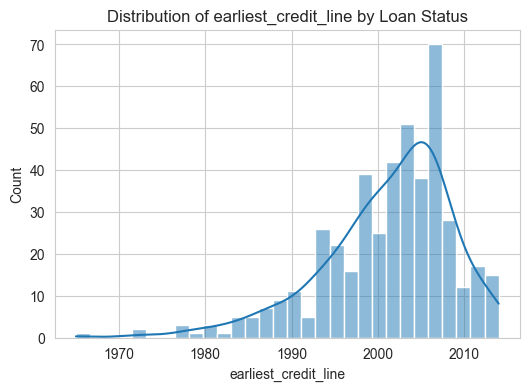

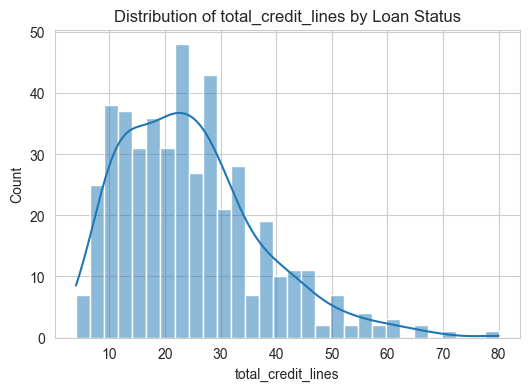

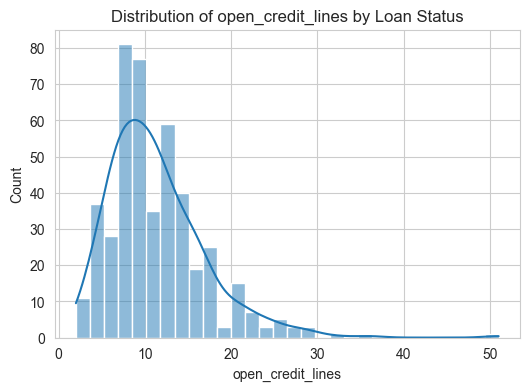

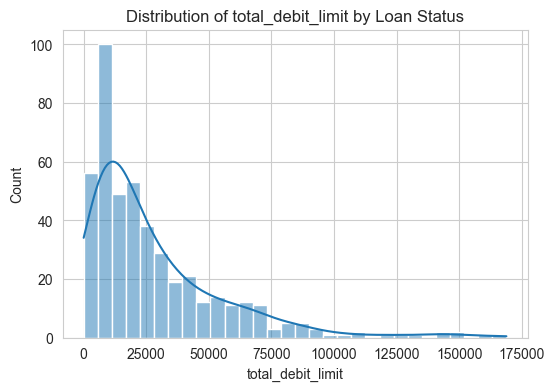

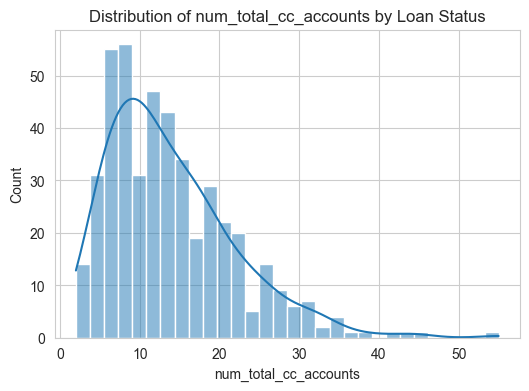

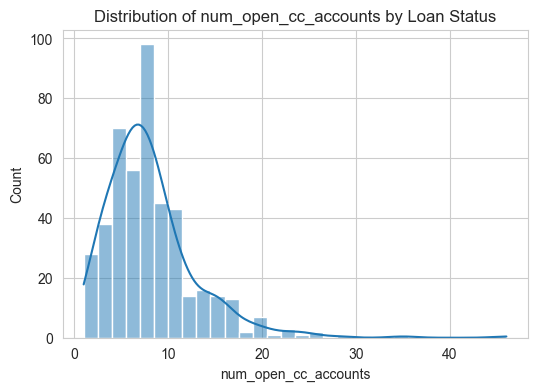

In [25]:
# Distribution of key financial variables
# What does a “typical borrower” look like? --> annual_income, debt_to_income, emp_length, loan_amnt

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 4) # Set default figure size

# Pre loan variables
num_vars_pre_loan = [
    "annual_income",
    "annual_income_joint",
    "debt_to_income",
    "emp_length",
    "delinq_2y",
    "months_since_last_delinq",
    "months_since_90d_late",
    "num_historical_failed_to_pay",
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts"
]

# Categorical variables
cat_vars_pre_loan = [
    "homeownership",
    "public_record_bankrupt",
    "tax_liens",
    "loan_purpose",
    "application_type",
    "state",
    "emp_title"
]

# histograms for numerical variables
for var in num_vars_pre_loan:
    plt.figure()
    # sns.histplot(data=df_credit, x=var, hue="loan_status", kde=True, element="step", stat="density", common_norm=False)
    ax = sns.histplot(df_credit[var], bins=30, kde=True)
    ax.ticklabel_format(style="plain", axis="x") # So we can see large numbers properly
    plt.title(f"Distribution of {var} by Loan Status")
    plt.show()




## 2. Distribution of Key Financial Variables

* **Annual income:** concentrated roughly between **0–50k** in your sample; behaves fairly regular in that range.
* **Debt-to-income (DTI):** fairly regular, mostly **0–50**, making it a stable affordability proxy.
* **Employment length (`emp_length`):** broadly spread but with a **clear spike at 10 years** (likely rounding/binning in how it’s reported).
* **Credit lines:**

  * `total_credit_lines` ~ normal-like, **median ~20**
  * `open_credit_lines` ~ normal-like, **median ~9**
* **Earliest credit line:** centered around **~2005** (proxy for credit history length).


In [26]:
# Relationship between borrower characteristics and default

# Keep only loans with a final outcome
df_pd = df_credit.copy()

# Binary target: 1 = default, 0 = non-default
df_pd["default"] = (df_pd["loan_status"] == "Charged Off").astype(int)

print("Sample size:", df_pd.shape[0])
print("Default rate:", df_pd["default"].mean().round(4))
df_pd["default"].value_counts()


Sample size: 454
Default rate: 0.0154


default
0    447
1      7
Name: count, dtype: int64

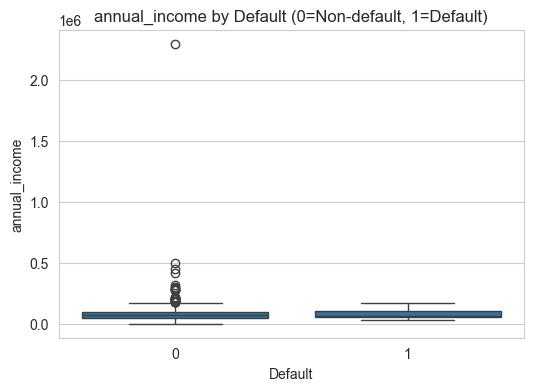

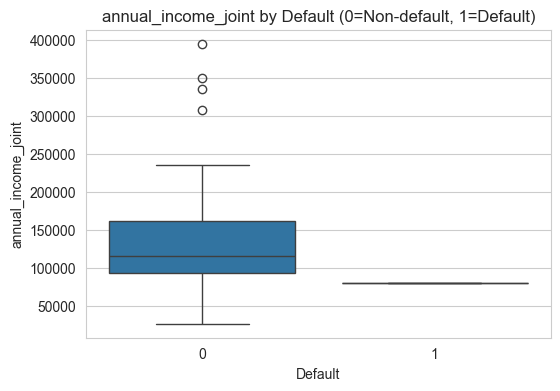

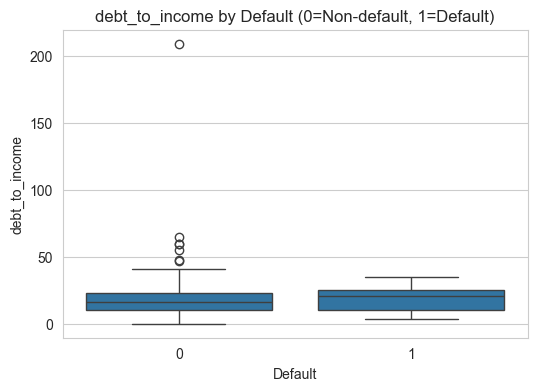

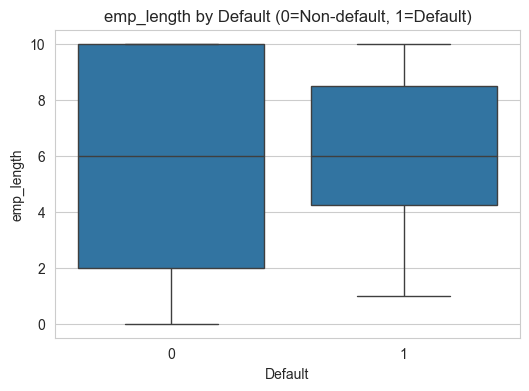

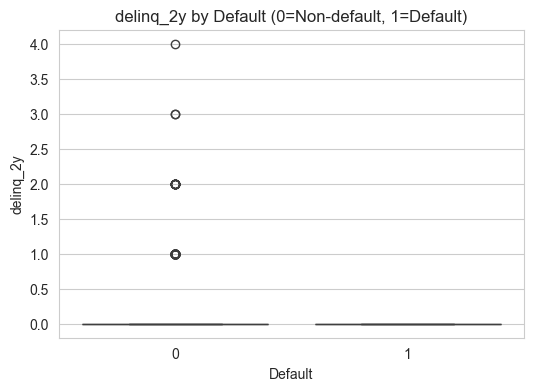

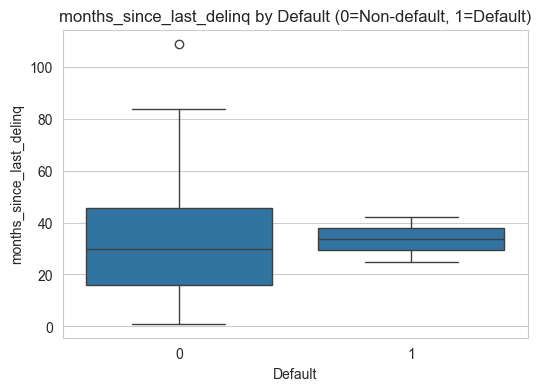

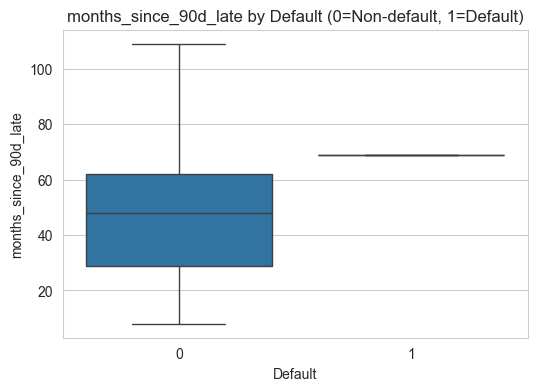

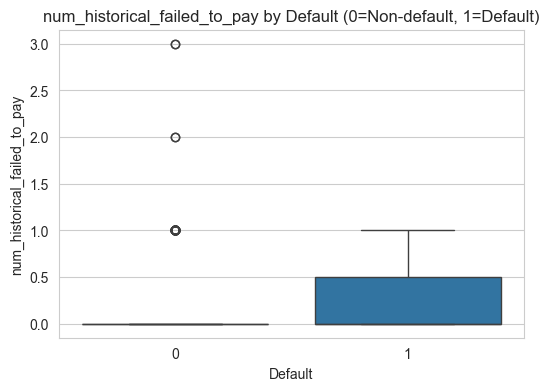

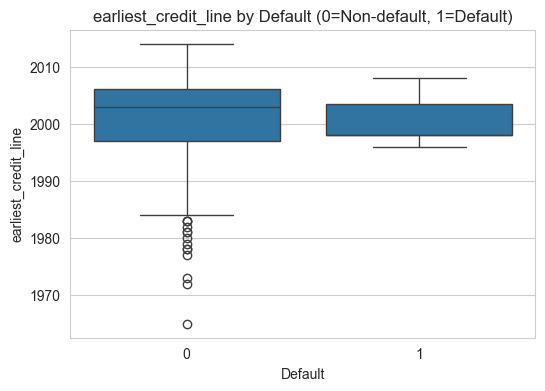

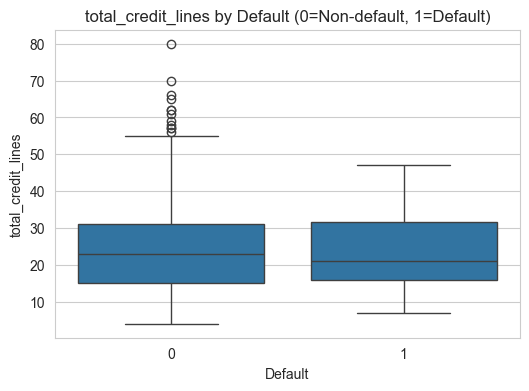

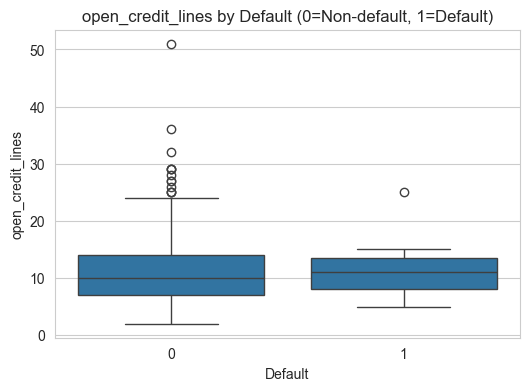

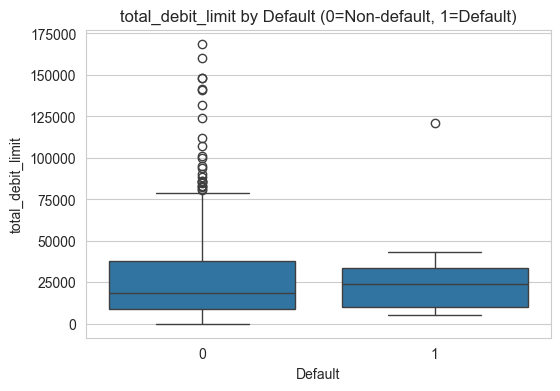

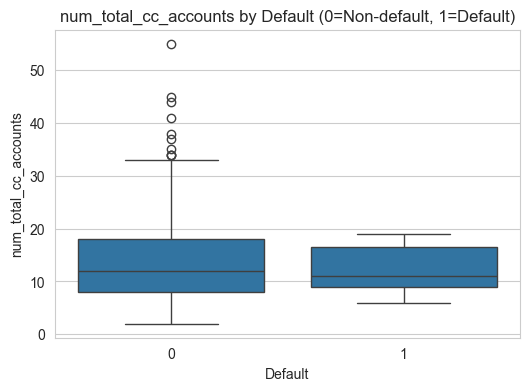

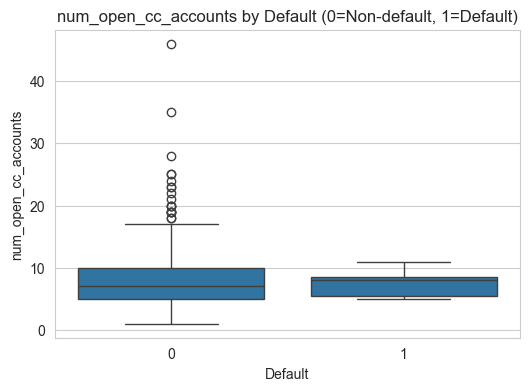

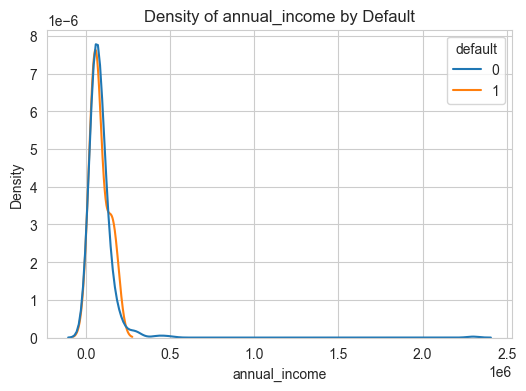

/var/folders/ly/kvgv_mks3jb2b_3_qy4l9s3c0000gn/T/ipykernel_43534/1755304882.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_pd, x=var, hue="default", common_norm=False) # common_norm=False to compare densities


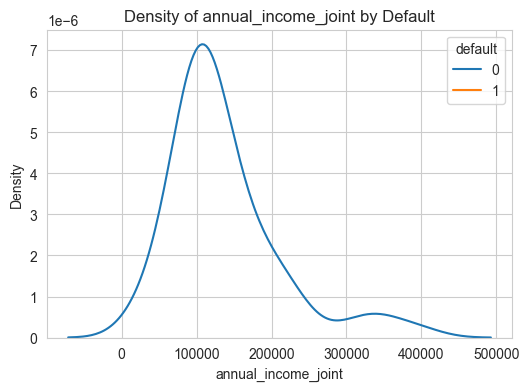

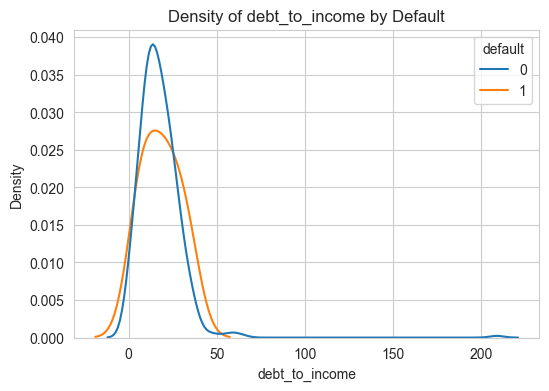

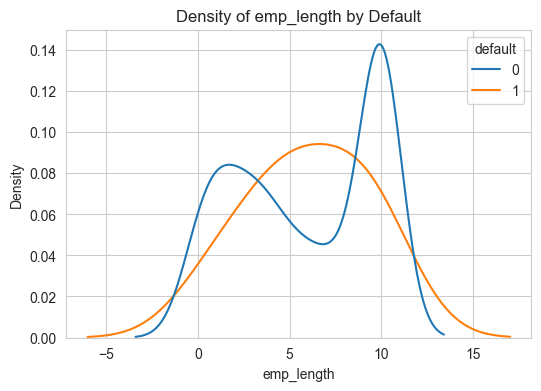

/var/folders/ly/kvgv_mks3jb2b_3_qy4l9s3c0000gn/T/ipykernel_43534/1755304882.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_pd, x=var, hue="default", common_norm=False) # common_norm=False to compare densities


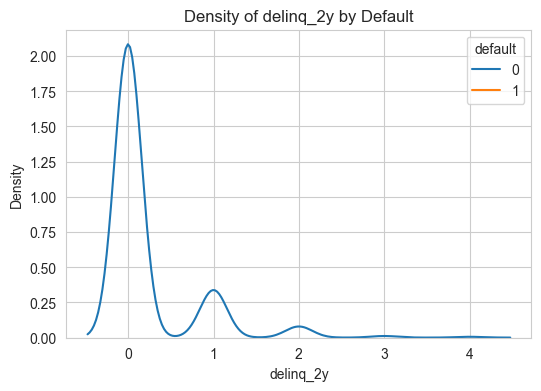

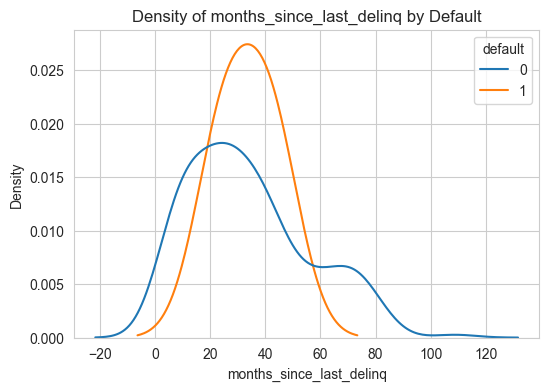

/var/folders/ly/kvgv_mks3jb2b_3_qy4l9s3c0000gn/T/ipykernel_43534/1755304882.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_pd, x=var, hue="default", common_norm=False) # common_norm=False to compare densities


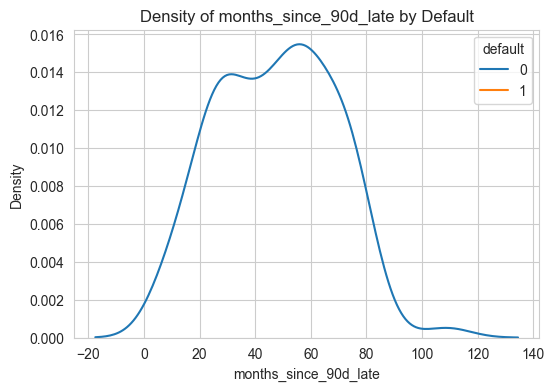

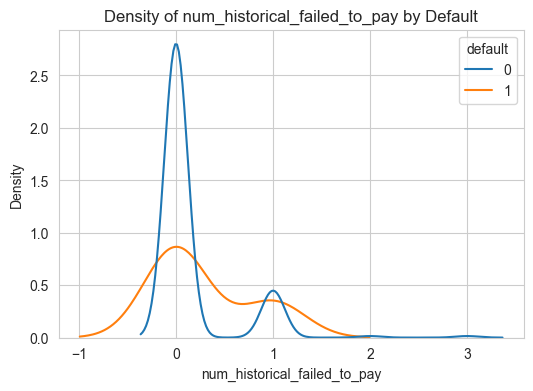

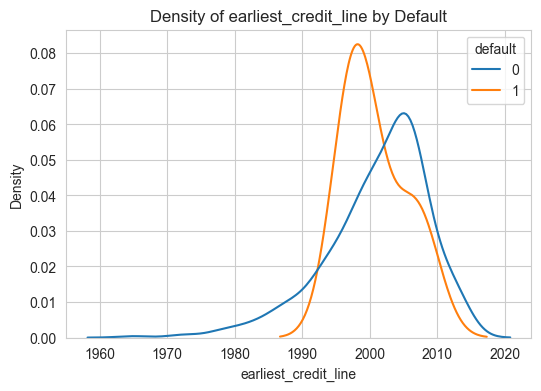

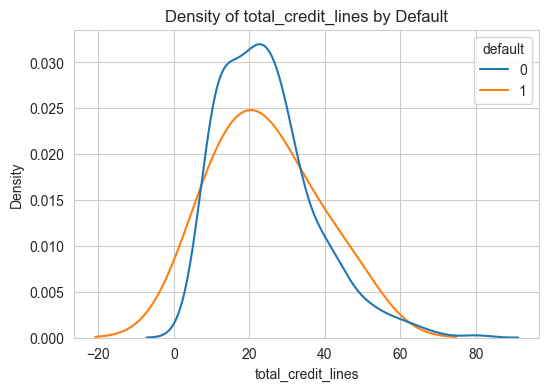

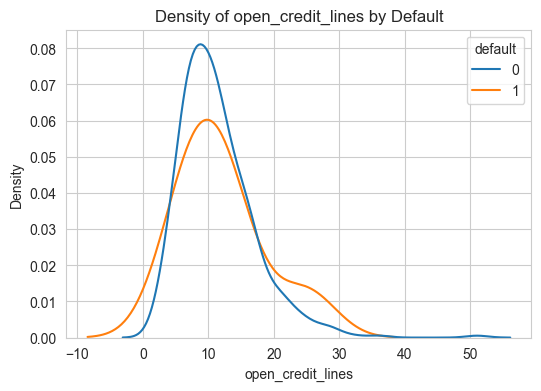

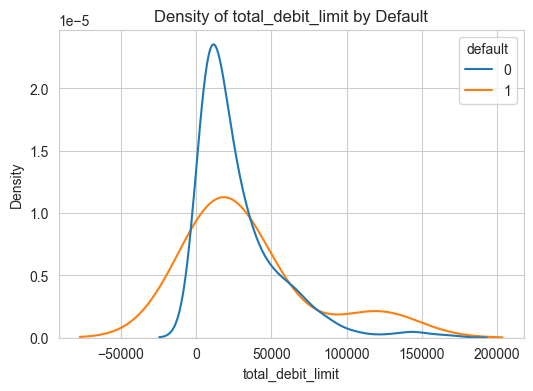

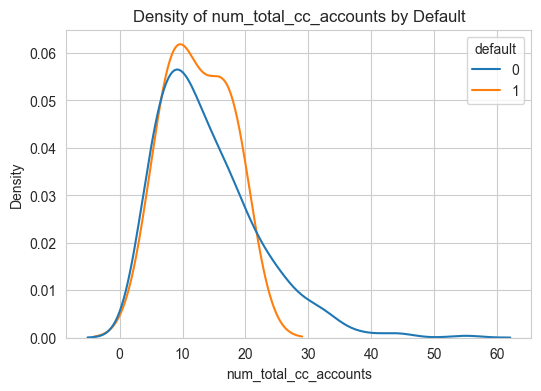

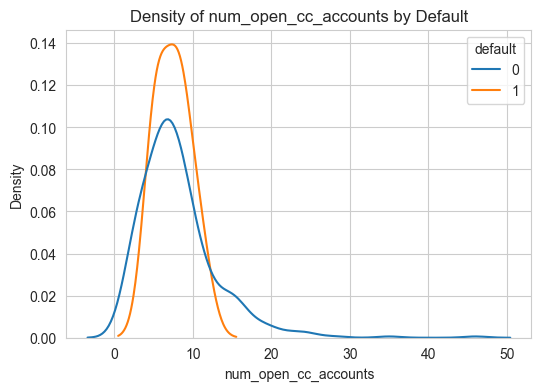

In [27]:
# Boxplots
for var in num_vars_pre_loan:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_pd, x="default", y=var)
    plt.title(f"{var} by Default (0=Non-default, 1=Default)")
    plt.xlabel("Default")
    plt.ylabel(var)
    plt.show()

# Density plots
for var in num_vars_pre_loan:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df_pd, x=var, hue="default", common_norm=False) # common_norm=False to compare densities
    plt.title(f"Density of {var} by Default")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.show()


In [28]:
delinq_2y_df = df_credit.loc[df_credit["loan_status"] == "Charged Off", "delinq_2y"]
months_since_90d_late_df = df_credit.loc[df_credit["loan_status"] == "Charged Off", "months_since_90d_late"]
num_historical_failed_to_pay_df = df_credit.loc[df_credit["loan_status"] == "Charged Off", "num_historical_failed_to_pay"]

print(delinq_2y_df.describe()) # No Charged Off have delinq_2y
print(months_since_90d_late_df.describe())
print(num_historical_failed_to_pay_df.describe())

count    7.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: delinq_2y, dtype: float64
count     1.0
mean     69.0
std       NaN
min      69.0
25%      69.0
50%      69.0
75%      69.0
max      69.0
Name: months_since_90d_late, dtype: float64
count    7.000000
mean     0.285714
std      0.487950
min      0.000000
25%      0.000000
50%      0.000000
75%      0.500000
max      1.000000
Name: num_historical_failed_to_pay, dtype: float64


### Sample overview

* **Total observations:** 454
* **Defaults:** 7
* **Non-defaults:** 447
* **Default rate:** 1.54%


### 3.1 Income and Leverage Variables

**Annual income**

* Boxplots show very similar medians for defaulted and non-defaulted borrowers.
* Non-defaulted loans exhibit **more extreme outliers**, reflecting a wider income range.
* Density plots confirm a roughly **normal distribution** for both groups, with no strong separation.

**Debt-to-income ratio**

* Variability is similar across both groups.
* The **median debt-to-income is lower for non-defaulted borrowers**, which is consistent with financial intuition.
* Density curves largely overlap, although defaulted borrowers show slightly higher leverage on average.

**Interpretation:**
Income and leverage alone do not clearly separate defaults, although debt burden shows a weak directional signal.


### 3.2 Employment Stability

**Employment length**

* Boxplots show **similar medians** for both groups.
* Non-defaulted borrowers have a **wider and taller distribution**, indicating more heterogeneity in employment history.
* Density plots reveal:

  * Defaulted loans follow a roughly **normal distribution**
  * Non-defaulted loans show a **non-normal, bimodal shape**

**Interpretation:**
Employment length may carry some information, but the relationship is not monotonic and likely interacts with other variables.


### 3.3 Past Delinquency and Credit Behaviour

**Delinquencies in the last 2 years (`delinq_2yr`)**

* Median is very low (close to zero) for both groups.
* Non-defaulted loans show **more outliers**, suggesting rare but extreme delinquency histories.
* Density plots for defaults are almost non-existent due to scarcity.

**Months since last delinquency**

* Non-defaulted borrowers have a **lower median** and a **wider box**, indicating more dispersion.
* Defaulted borrowers show a narrower distribution.
* Density plots are approximately normal for both groups, but flatter for non-defaults.

**Months since 90-day late**

* Defaulted loans collapse to a **single line**, indicating almost no variability.
* Non-defaulted loans show a wider distribution with a median around 50 months.
* Due to lack of variability for defaults, this variable is **unlikely to be informative** and may be excluded.

**Historical failed payments**

* Non-defaulted loans have a **median of zero**, with some outliers.
* Defaulted loans have a **median around 1**, but the box overlaps heavily with zero.
* Density plots show:

  * Non-defaults with a **bimodal shape and sharp peaks**
  * Defaults closer to a normal distribution with lower density

**Interpretation:**
Past credit behaviour shows some intuitive patterns, but sparsity and overlap limit its standalone explanatory power.


### 3.4 Credit History and Credit Lines

**Earliest credit line**

* Defaulted borrowers tend to have **older credit histories**.
* Density plots show:

  * Defaults peak around **1997** with a higher density
  * Non-defaults peak later (around **2005**) with a lower density
* This suggests that older credit history does not necessarily imply lower default risk.

**Total credit lines**

* Non-defaulted loans have a **higher median** (around 25) compared to defaults (around 20).
* Box sizes are similar, indicating comparable dispersion.
* Both groups follow approximately normal distributions, with a higher peak for non-defaults.

**Open credit lines**

* Defaulted borrowers show a **slightly higher median** (around 12) than non-defaults (around 10).
* Non-defaulted loans have a wider spread and higher density peak.

**Interpretation:**
Credit line variables show moderate differences, but no strong separation. They may be useful in combination with other features rather than individually.


### 3.5 Key Takeaways

* Most borrower characteristics show **substantial overlap** between defaulted and non-defaulted loans.
* Variables related to **leverage, credit history length, and past delinquency** show weak but intuitive directional signals.
* Some features (e.g. months since 90-day late) provide **little to no information** due to lack of variability.
* Given the **extreme class imbalance**, conclusions are exploratory and primarily used to:

  * Guide feature selection
  * Inform transformations
  * Motivate regularisation and imbalance-aware modeling techniques




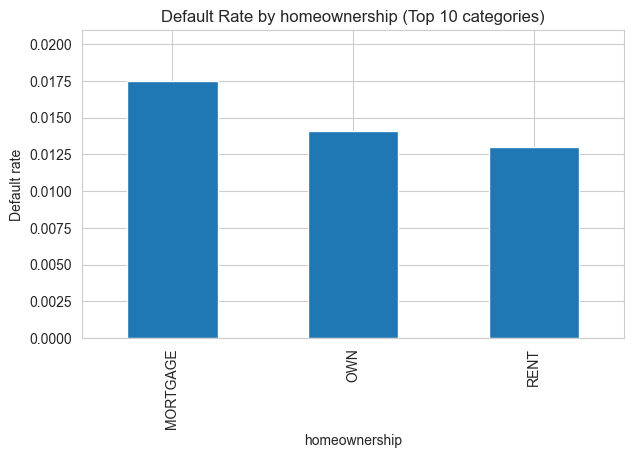

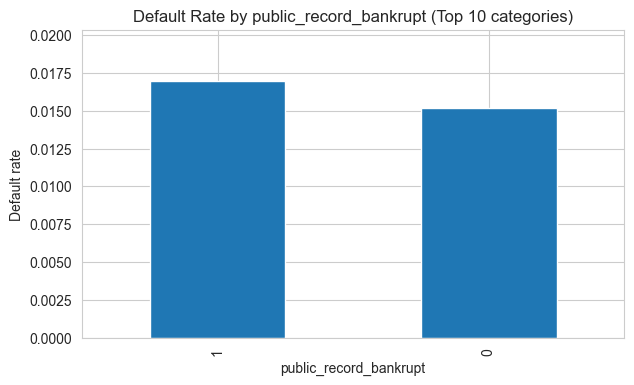

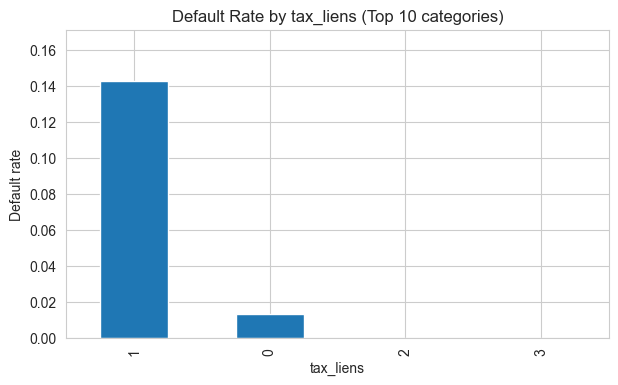

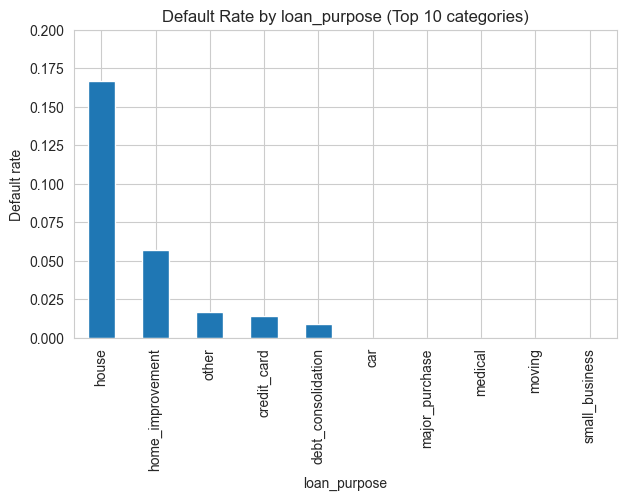

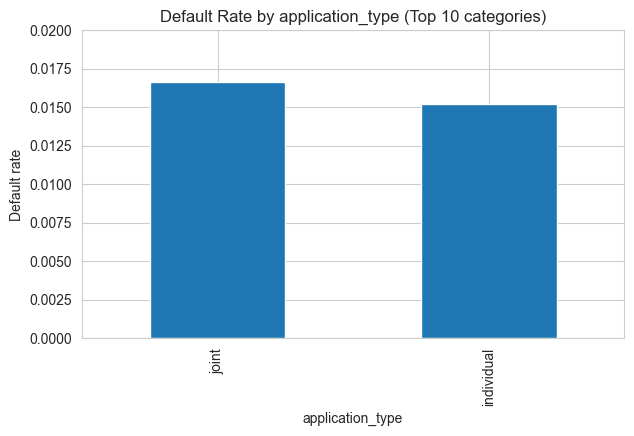

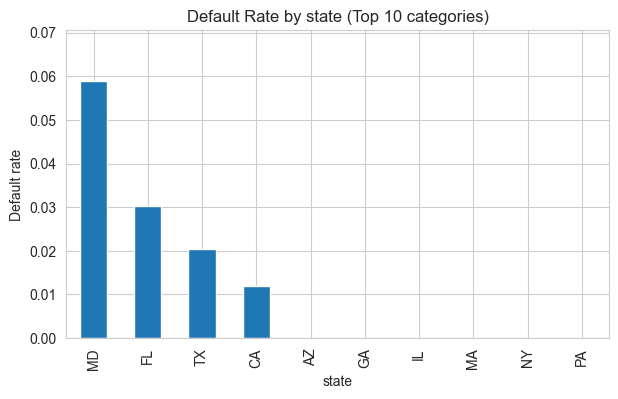

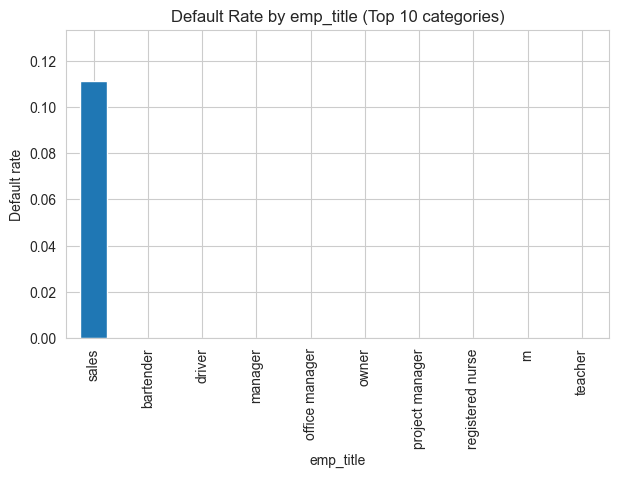

In [29]:
# 0j
for var in cat_vars_pre_loan:
    # Compute default rate by category
    rate = df_pd.groupby(var)["default"].mean().sort_values(ascending=False)

    # For high-cardinality categories, show only top 10 by frequency
    counts = df_pd[var].value_counts()
    top_cats = counts.head(10).index
    rate_top = df_pd[df_pd[var].isin(top_cats)].groupby(var)["default"].mean().sort_values(ascending=False)

    plt.figure(figsize=(7, 4))
    rate_top.plot(kind="bar")
    plt.title(f"Default Rate by {var} (Top 10 categories)")
    plt.xlabel(var)
    plt.ylabel("Default rate")
    plt.ylim(0, min(1, rate_top.max() * 1.2))
    plt.show()


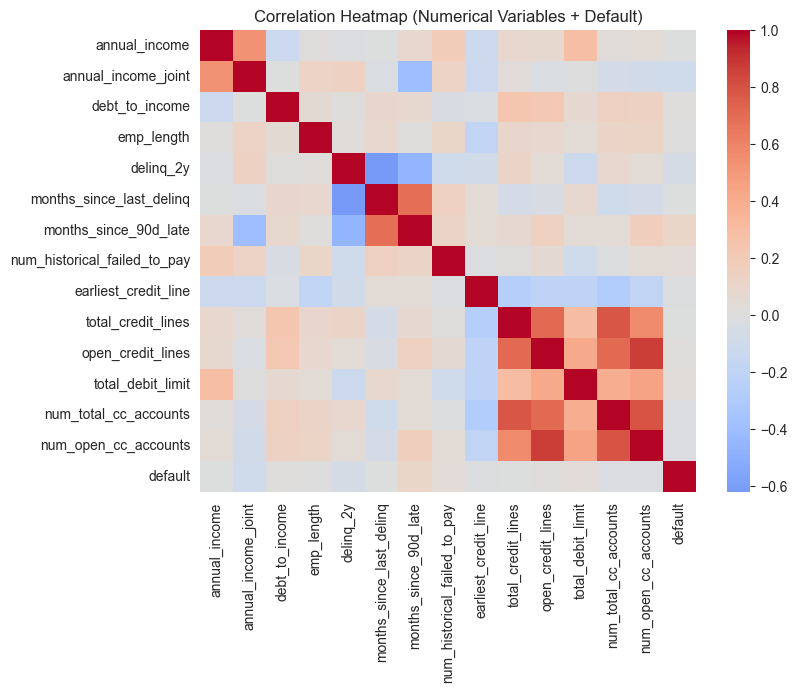

default                         1.000000
months_since_90d_late           0.106097
num_historical_failed_to_pay    0.037895
total_debit_limit               0.026864
open_credit_lines               0.014105
debt_to_income                  0.008965
emp_length                      0.002299
months_since_last_delinq       -0.001054
total_credit_lines             -0.002847
annual_income                  -0.003179
earliest_credit_line           -0.006844
num_open_cc_accounts           -0.016019
num_total_cc_accounts          -0.022912
delinq_2y                      -0.050706
annual_income_joint            -0.098438
Name: default, dtype: float64

In [30]:
# correlation check (numerical only)
corr = df_pd[num_vars_pre_loan + ["default"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Variables + Default)")
plt.show()

corr["default"].sort_values(ascending=False)


## 3.6 Default Rates Across Categorical Variables

In addition to numerical borrower characteristics, default behaviour can also vary across **categorical features** that capture ownership status, credit events, loan intent, and application structure. To improve readability and statistical stability, only **top-N categories** are shown where applicable.


### Homeownership Status

Default rates differ meaningfully across homeownership categories:

* **Mortgage** borrowers exhibit the **highest default rate**
* Followed by **homeowners (own)**
* **Renters** show the lowest default rate among the three

**Interpretation:**
Borrowers with mortgages may carry higher fixed obligations, increasing financial stress during adverse shocks. Homeownership alone is therefore not a guarantee of lower default risk.


### Public Records and Legal Events

**Public record bankruptcies**

* Default rate is noticeably higher among borrowers with **public record bankruptcies**
* Non-defaulted loans dominate the zero-bankruptcy group

**Tax liens**

* A strong contrast is observed:

  * Default rate around **0.14** when tax liens are present
  * Around **0.01** when no tax liens exist
* Categories with 2 or 3 tax liens appear empty or too sparse for interpretation

**Interpretation:**
Legal and tax-related credit events are among the **strongest categorical risk indicators** observed in this EDA, despite their low frequency.


### Loan Purpose (Top Categories)

Focusing on the most common loan purposes:

* **House** loans show the **highest default rate** (≈ **0.16**)
* **Home improvement** follows (≈ **0.06**)
* Remaining purposes cluster at lower rates:

  * Credit card
  * Debt consolidation
  * Car

**Interpretation:**
Larger, long-term or property-related loans appear riskier in relative terms. However, sample size effects are likely, and these results should be treated as **indicative rather than definitive**.


### Application Type

* **Joint applications** have a slightly higher default rate (≈ **0.0160**)
* **Individual applications** show a marginally lower rate (≈ **0.0150**)

**Interpretation:**
The difference is minimal and unlikely to be statistically significant on its own, suggesting application type alone is not a strong risk driver.


### Correlation view (with default)

Correlations with default are weak overall (expected with rare events), but directionally:

* `months_since_90d_late` has the strongest positive correlation (~**0.106**),
* `num_historical_failed_to_pay` is small positive (~**0.038**),
* `delinq_2y` slightly negative (~**-0.051**).

In [31]:
# Comparison of good vs bad borrowers
for var in num_vars_pre_loan:
    mean_good = df_pd[df_pd["default"] == 0][var].mean()
    mean_bad = df_pd[df_pd["default"] == 1][var].mean()
    diff = mean_bad - mean_good
    print(f"{var}: Mean Good = {mean_good:.2f}, Mean Bad = {mean_bad:.2f}, Difference = {diff:.2f}")

for var in cat_vars_pre_loan:
    default_rates = df_pd.groupby(var)["default"].mean()
    print(f"\nDefault rates by {var}:")
    print(default_rates.sort_values(ascending=False))

annual_income: Mean Good = 86609.05, Mean Bad = 83554.29, Difference = -3054.76
annual_income_joint: Mean Good = 135980.66, Mean Bad = 80000.00, Difference = -55980.66
debt_to_income: Mean Good = 17.48, Mean Bad = 18.46, Difference = 0.97
emp_length: Mean Good = 5.93, Mean Bad = 6.00, Difference = 0.07
delinq_2y: Mean Good = 0.22, Mean Bad = 0.00, Difference = -0.22
months_since_last_delinq: Mean Good = 33.73, Mean Bad = 33.50, Difference = -0.23
months_since_90d_late: Mean Good = 47.30, Mean Bad = 69.00, Difference = 21.70
num_historical_failed_to_pay: Mean Good = 0.16, Mean Bad = 0.29, Difference = 0.13
earliest_credit_line: Mean Good = 2001.14, Mean Bad = 2000.71, Difference = -0.42
total_credit_lines: Mean Good = 24.58, Mean Bad = 24.29, Difference = -0.29
open_credit_lines: Mean Good = 11.34, Mean Bad = 12.00, Difference = 0.66
total_debit_limit: Mean Good = 27945.92, Mean Bad = 33985.71, Difference = 6039.80
num_total_cc_accounts: Mean Good = 13.91, Mean Bad = 12.43, Difference =

## 4. Comparison Between Good and Bad Borrowers

**Class split:** 447 non-default vs 7 default → conclusions are **directional**, not definitive. Still, your boxplots/densities + mean differences give some usable signals.

### Numerical differences (means)

* **Income:** Bad slightly lower

  * Good: 86.6k vs Bad: 83.6k (−3.1k)
* **DTI:** Bad slightly higher

  * Good: 17.48 vs Bad: 18.46 (+0.97)
* **Employment length:** almost identical

  * Good: 5.93 vs Bad: 6.00
* **`delinq_2y`:** Bad appears lower (0.00) than Good (0.22)

  * This is counterintuitive and likely a **small-sample artifact** (with 7 defaults, one subgroup can skew averages).
* **`months_since_90d_late`:** Bad higher

  * Good: 47.3 vs Bad: 69.0 (+21.7)
* **`num_historical_failed_to_pay`:** Bad higher

  * Good: 0.16 vs Bad: 0.29 (+0.13)
* **Credit lines:** Bad slightly higher open lines

  * Open credit lines: Good 11.34 vs Bad 12.00 (+0.66)

### Categorical default rates (descriptive, very sensitive to small counts)

* **Tax liens** stand out:

  * `tax_liens = 1` → **14.3%** default vs `0` → **1.35%**
    This is likely a *tiny subgroup*, but economically it makes sense as a red-flag indicator.
* **Loan purpose:** higher default rates appear for `house` (16.7%) and `home_improvement` (5.7%), but again likely small sample sizes.
* **Homeownership / bankrupt / application type:** differences are small.

## Exploratory Data Analysis (EDA) — Summary of Findings

### 1. Data Scope and Target Definition

The analysis is restricted to **information available at application time**, ensuring that all insights and subsequent models remain realistic and free from data leakage.

To define a clean target, loans were filtered to those with **final observed outcomes** only:

* **Fully Paid** → non-default
* **Charged Off** → default

After filtering, the dataset contains **454 observations**, with **447 non-defaults** and **7 defaults**, corresponding to a **default rate of approximately 1.54%** (min/max ratio ≈ **0.0157**).

This confirms that the problem is a **rare-event classification task**. As a result, overall accuracy is not an appropriate evaluation metric, and model development must focus on minority-class–sensitive metrics and cost-aware decision thresholds.


### 2. Distribution of Key Financial Variables

Borrower financial variables exhibit **non-Gaussian distributions and significant heterogeneity**:

* **Annual income** is concentrated roughly between **0–50k** in this sample, with a right tail driven by a small number of high-income borrowers.
* **Debt-to-income (DTI)** behaves relatively regularly, mostly within **0–50**, making it a stable affordability indicator.
* **Employment length** is broadly distributed, with a clear spike at **10 years**, likely reflecting reporting or binning effects.
* **Credit line variables** are approximately normal:

  * `total_credit_lines` with a median around **20**
  * `open_credit_lines` with a median around **9**
* **Earliest credit line** is centered around **~2005**, acting as a proxy for credit history length.

Overall, the presence of skewness and outliers suggests that raw financial variables are not directly suitable for modeling without **transformations, capping, or robust scaling**.


### 3. Credit History and Past Behaviour

Credit history variables are **sparse but economically meaningful**:

* Most borrowers show **no recent delinquencies**, but those with adverse credit events tend to display higher default risk.
* Variables such as `delinq_2yr`, `months_since_last_delinq`, and historical failed payments exhibit heavy overlap between defaulted and non-defaulted loans.
* `months_since_90d_late` shows almost **no variability among defaulters**, indicating limited standalone usefulness.
* **Earliest credit line** differs across classes: defaulters tend to have **older credit histories**, suggesting that a longer history does not necessarily imply lower risk.

Linear correlations with default are weak overall (as expected in rare-event settings), but directionally consistent:

* `months_since_90d_late`: positive (~**0.106**)
* `num_historical_failed_to_pay`: small positive (~**0.038**)
* `delinq_2yr`: slightly negative (~**−0.051**)

These results indicate that credit history variables may contribute signal primarily **in combination with other features**, rather than in isolation.


### 4. Comparison Between Good and Bad Borrowers

Given the extreme class imbalance (447 vs 7), all comparisons are **directional rather than definitive**.

**Numerical differences:**

* Defaulters exhibit **slightly lower income** and **higher DTI**
* **Employment length** is nearly identical across groups
* Defaulters show higher values for:

  * `months_since_90d_late`
  * `num_historical_failed_to_pay`
  * number of **open credit lines**

Some counterintuitive patterns (e.g. lower average `delinq_2yr` among defaulters) are likely **small-sample artifacts** rather than true economic effects.

**Categorical patterns:**

* Higher default rates are observed for:

  * **Mortgage** homeownership
  * Borrowers with **public record bankruptcies**
  * **Tax liens**, which stand out strongly (≈14% vs ≈1% when absent)
  * Loan purposes related to **house** and **home improvement**
* Differences by application type (joint vs individual) are minimal.

Overall, no single variable cleanly separates good and bad borrowers; default risk emerges from **interactions across leverage, credit history, and adverse behavioural signals**.


### 5. Data Quality and Modeling Implications

The EDA leads to several clear implications for modeling:

* **Extreme class imbalance** requires:

  * Minority-class–focused metrics (PR-AUC, recall, precision)
  * Possible class weighting or threshold tuning
* **Skewed distributions and outliers** motivate:

  * Robust preprocessing pipelines
  * Feature transformations rather than raw values
* **Sparse but high-impact variables** (e.g. tax liens, bankruptcies) must be handled carefully to avoid instability.
* Observed patterns are **economically coherent**, increasing confidence in both the dataset and downstream modeling choices.

**Final takeaway:**
Default risk in this dataset is a **rare, multifactor outcome** that cannot be captured by simple rules. This strongly motivates the use of **regularised, multivariate models** with careful validation and business-aware decision thresholds.